# Notebook 10 - Dimensionality Reduction

This notebook is the bridge between clustering and neural networks. The feature table has hundreds of audio summary columns, and not all of them carry separate information. Dimensionality reduction asks how much of that structure can be compressed without losing the useful signal.

The from-scratch part here is MiniLearn PCA. sklearn PCA is used as a sanity check, and t-SNE is used only as a visualization tool. I am not pretending t-SNE is a clean feature engineering step for the final classifier; it is mostly for seeing neighborhoods in 2D.

In [1]:
from pathlib import Path
import sys
import time
import warnings

ROOT = Path.cwd()
if not (ROOT / "features" / "features.csv").exists():
    maybe_root = ROOT.parent
    if (maybe_root / "features" / "features.csv").exists():
        ROOT = maybe_root
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans as SkKMeans
from sklearn.decomposition import PCA as SkPCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score, normalized_mutual_info_score, silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from minilearn.classifiers import LogisticRegression
from minilearn.preprocessing import PCA, StandardScaler, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 432
FEATURE_PATH = ROOT / "features" / "features.csv"

## Load and scale the feature table

PCA and t-SNE are both sensitive to scale. The feature table mixes MFCCs, mel summaries, RMS, centroid, and other values that live on different numeric ranges, so standardization is not optional here.

For the supervised comparison later, scaling and PCA are fit on the training split only. For the unsupervised visualization sections, the full scaled table is okay because the goal is exploration, not final test-set scoring.

In [2]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)

scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

print(f"rows={len(df)}, original_features={len(feature_cols)}, classes={len(labels)}")
print(emotion_names)

rows=2452, original_features=407, classes=8
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## MiniLearn PCA explained variance

PCA rotates the feature space into components ordered by variance. High variance does not automatically mean "emotion signal," but the explained variance curve tells us how compressible the feature table is.

This is also where PCA starts to be useful conceptually: if 30 or 50 components keep a lot of the variance from 407 original features, then some of the original columns are redundant or correlated.

In [3]:
full_pca = PCA(n_components=min(X_scaled.shape))
X_pca_full = full_pca.fit_transform(X_scaled)
cum_var = np.cumsum(full_pca.explained_variance_ratio_)

checkpoints = [2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 407]
checkpoints = [c for c in checkpoints if c <= len(cum_var)]
variance_table = pd.DataFrame({
    "components": checkpoints,
    "cumulative_variance": [cum_var[c - 1] for c in checkpoints],
})
variance_table["cumulative_variance"] = variance_table["cumulative_variance"].round(4)
variance_table

,components,cumulative_variance
0,2,0.4564
1,5,0.6201
2,10,0.7130
3,20,0.8048
4,30,0.8558
5,50,0.9112
6,75,0.9473
7,100,0.9678
8,150,0.9888
9,200,0.9966


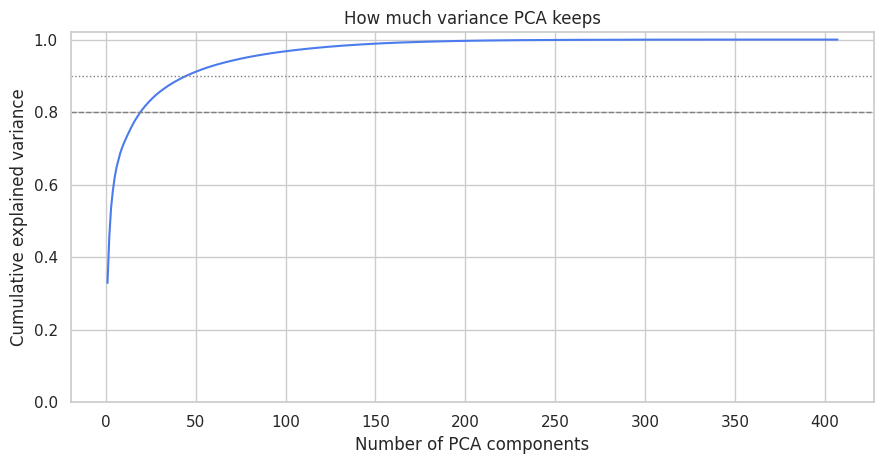

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, color="#4b7bec")
ax.axhline(0.80, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.90, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("How much variance PCA keeps")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## MiniLearn PCA vs sklearn PCA sanity check

PCA component signs can flip and still be correct. A component vector and its negative represent the same axis. So the sanity check below compares explained variance ratios and absolute component alignment instead of expecting every value to match with the same sign.

In [5]:
mini_check = PCA(n_components=10).fit(X_scaled)
sk_check = SkPCA(n_components=10, random_state=RANDOM_STATE).fit(X_scaled)

alignments = []
for i in range(10):
    alignments.append(abs(np.dot(mini_check.components_[i], sk_check.components_[i])))

pca_check = pd.DataFrame({
    "component": np.arange(1, 11),
    "minilearn_var_ratio": mini_check.explained_variance_ratio_,
    "sklearn_var_ratio": sk_check.explained_variance_ratio_,
    "abs_component_alignment": alignments,
})
pca_check.round(6)

,component,minilearn_var_ratio,sklearn_var_ratio,abs_component_alignment
0,1,0.328806,0.328806,1.000000
1,2,0.127637,0.127637,1.000000
2,3,0.080587,0.080587,1.000000
3,4,0.046977,0.046977,1.000000
4,5,0.036044,0.036044,1.000000
5,6,0.027202,0.027202,1.000000
6,7,0.019466,0.019466,1.000000
7,8,0.018818,0.018818,1.000000
8,9,0.014661,0.014661,0.999998
9,10,0.012827,0.012827,0.999995


## 2D PCA visualization

Two components are not enough to preserve the whole dataset, but they are useful for a quick plot. The point is not to expect perfectly separated emotion islands. If there is overlap here, that explains why simple models struggle.

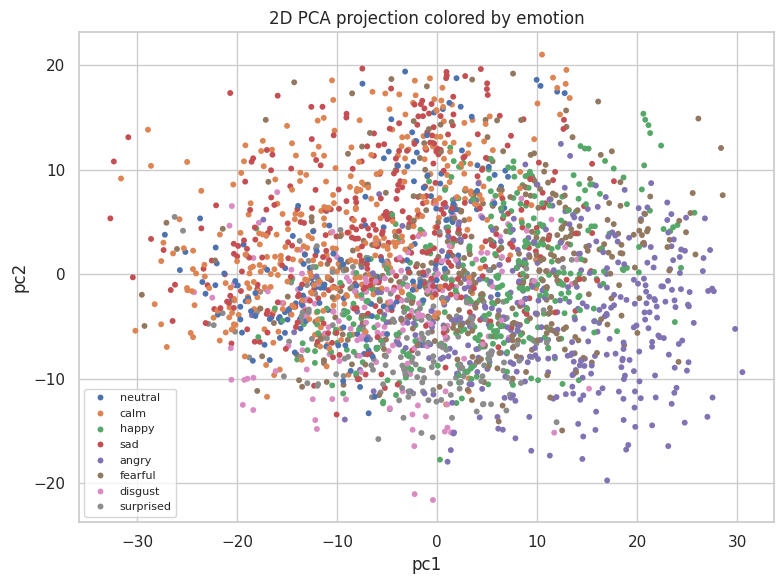

In [6]:
X_pca2 = X_pca_full[:, :2]
pca2_df = pd.DataFrame({
    "pc1": X_pca2[:, 0],
    "pc2": X_pca2[:, 1],
    "emotion": [emotion_names[i] for i in y],
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=pca2_df, x="pc1", y="pc2", hue="emotion", s=18, linewidth=0, ax=ax)
ax.set_title("2D PCA projection colored by emotion")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Reconstruction error

Reconstruction error asks: if we compress the data to `k` components and rebuild it, how far is the rebuilt version from the scaled original features?

This is not a classifier score. It is just a compression score. Low reconstruction error means PCA preserved the broad feature geometry, not necessarily the emotion labels.

In [7]:
centered = X_scaled - full_pca.mean_
recon_rows = []
for k in checkpoints:
    comps = full_pca.components_[:k]
    recon = centered @ comps.T @ comps + full_pca.mean_
    mse = np.mean((X_scaled - recon) ** 2)
    recon_rows.append({"components": k, "reconstruction_mse": mse, "cumulative_variance": cum_var[k - 1]})

recon_df = pd.DataFrame(recon_rows)
recon_df.round(5)

,components,reconstruction_mse,cumulative_variance
0,2,0.54356,0.45644
1,5,0.37995,0.62005
2,10,0.28697,0.71303
3,20,0.19517,0.80483
4,30,0.14422,0.85578
5,50,0.08882,0.91118
6,75,0.05273,0.94727
7,100,0.03219,0.96781
8,150,0.01120,0.98880
9,200,0.00342,0.99658


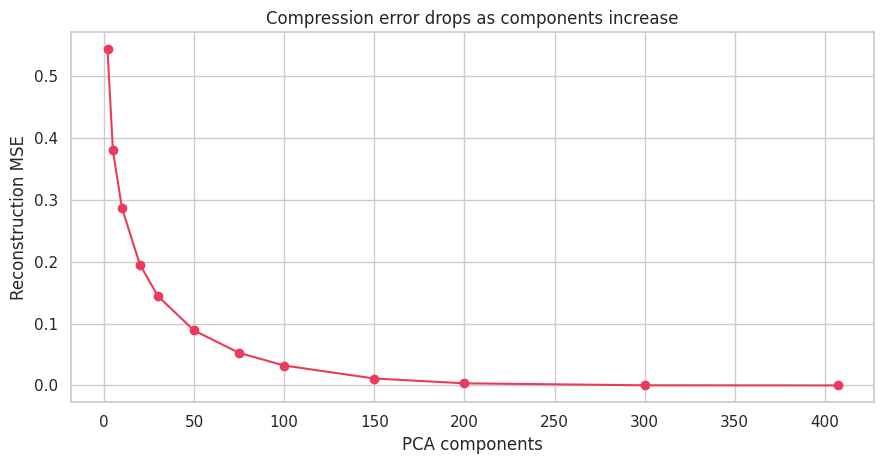

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 4.8))
ax1.plot(recon_df["components"], recon_df["reconstruction_mse"], marker="o", color="#eb3b5a")
ax1.set_xlabel("PCA components")
ax1.set_ylabel("Reconstruction MSE")
ax1.set_title("Compression error drops as components increase")
plt.tight_layout()
plt.show()

## Supervised models on original vs PCA features

Now PCA gets tested in a way that matters for the SER project: does reducing dimensions help or hurt held-out classification?

This uses the same split idea as the validation notebook. Scaling and PCA are fit on the training data only, then applied to the held-out test split. That avoids leaking test-set structure into training.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
train_scaler = StandardScaler()
X_train_s = train_scaler.fit_transform(X_train)
X_test_s = train_scaler.transform(X_test)

pca_sizes = [10, 30, 50, 100]
train_pca = PCA(n_components=max(pca_sizes)).fit(X_train_s)
X_train_pca_all = train_pca.transform(X_train_s)
X_test_pca_all = train_pca.transform(X_test_s)

model_specs = [
    ("MiniLearn Logistic Regression", lambda: LogisticRegression(learning_rate=0.08, max_iter=350, reg_strength=0.001, tol=1e-7)),
    ("sklearn RBF SVM", lambda: SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)),
    ("sklearn KNN", lambda: KNeighborsClassifier(n_neighbors=5, weights="distance")),
]

def fit_score(name, model, Xtr, Xte, feature_set):
    start = time.perf_counter()
    model.fit(Xtr, y_train)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    pred = model.predict(Xte)
    predict_seconds = time.perf_counter() - start
    return {
        "model": name,
        "feature_set": feature_set,
        "n_features": Xtr.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }

supervised_rows = []
for name, factory in model_specs:
    supervised_rows.append(fit_score(name, factory(), X_train_s, X_test_s, "original scaled"))
    for k in pca_sizes:
        supervised_rows.append(
            fit_score(name, factory(), X_train_pca_all[:, :k], X_test_pca_all[:, :k], f"PCA-{k}")
        )

supervised_results = pd.DataFrame(supervised_rows)
show_supervised = supervised_results.copy()
for col in ["accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]:
    show_supervised[col] = show_supervised[col].round(4)
show_supervised.sort_values(["model", "macro_f1"], ascending=[True, False])

,model,feature_set,n_features,accuracy,macro_f1,weighted_f1,fit_seconds,predict_seconds
0,MiniLearn Logistic Regression,original scaled,407,0.6851,0.6787,0.6842,0.9143,0.0005
4,MiniLearn Logistic Regression,PCA-100,100,0.6442,0.6380,0.6428,0.3772,0.0005
3,MiniLearn Logistic Regression,PCA-50,50,0.5930,0.5809,0.5935,0.3049,0.0002
2,MiniLearn Logistic Regression,PCA-30,30,0.5317,0.5198,0.5311,0.2904,0.0001
1,MiniLearn Logistic Regression,PCA-10,10,0.4213,0.4120,0.4196,0.3022,0.0002
10,sklearn KNN,original scaled,407,0.6728,0.6503,0.6720,0.0013,0.0701
14,sklearn KNN,PCA-100,100,0.6585,0.6400,0.6589,0.0007,0.0046
12,sklearn KNN,PCA-30,30,0.6401,0.6168,0.6371,0.0007,0.0045
13,sklearn KNN,PCA-50,50,0.6339,0.6107,0.6319,0.0010,0.0041
11,sklearn KNN,PCA-10,10,0.5378,0.5178,0.5341,0.0065,0.0068


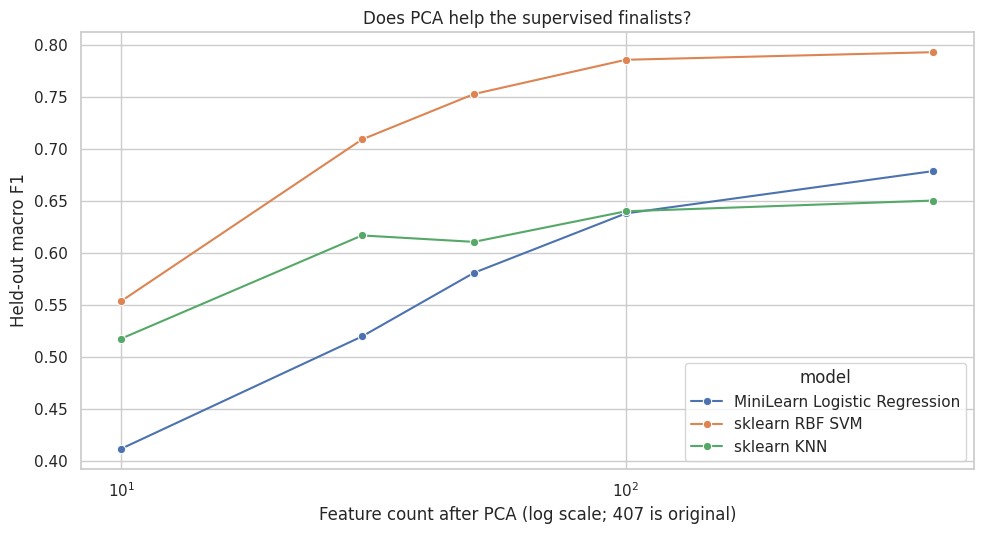

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=supervised_results, x="n_features", y="macro_f1", hue="model", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Feature count after PCA (log scale; 407 is original)")
ax.set_ylabel("Held-out macro F1")
ax.set_title("Does PCA help the supervised finalists?")
plt.tight_layout()
plt.show()

## K-Means on original vs PCA features

For clustering, PCA can sometimes help by removing noise and making distance calculations less chaotic. Here the comparison is simple: run K-Means with 8 clusters on original scaled features and PCA-reduced features, then compare ARI/NMI/silhouette.

In [11]:
cluster_rows = []
cluster_sets = [("original scaled", X_scaled)]
for k in [2, 10, 30, 50, 100]:
    cluster_sets.append((f"PCA-{k}", X_pca_full[:, :k]))

for feature_set, Xc in cluster_sets:
    km = SkKMeans(n_clusters=8, n_init=10, random_state=RANDOM_STATE)
    clusters = km.fit_predict(Xc)
    cluster_rows.append({
        "feature_set": feature_set,
        "n_features": Xc.shape[1],
        "inertia": km.inertia_,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "silhouette": silhouette_score(Xc, clusters),
    })

cluster_compare = pd.DataFrame(cluster_rows)
cluster_compare.round(4)

,feature_set,n_features,inertia,ARI,NMI,silhouette
0,original scaled,407,571641.7679,0.0839,0.1716,0.0980
1,PCA-2,2,70923.3839,0.0842,0.1741,0.3267
2,PCA-10,10,289203.5629,0.0832,0.1665,0.1690
3,PCA-30,30,428825.2447,0.0840,0.1709,0.1250
4,PCA-50,50,483513.3460,0.0822,0.1696,0.1148
5,PCA-100,100,539765.0490,0.0851,0.1689,0.1021


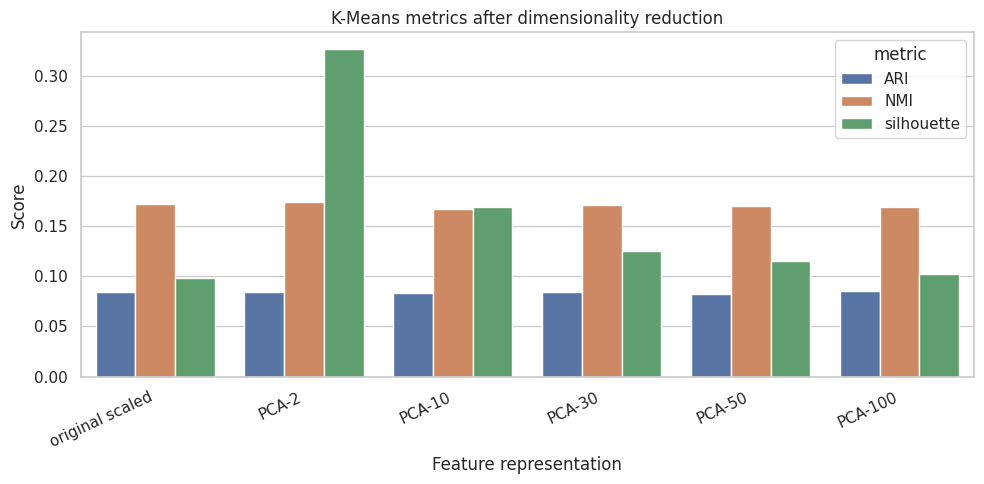

In [12]:
plot_cluster = cluster_compare.melt(
    id_vars=["feature_set", "n_features"],
    value_vars=["ARI", "NMI", "silhouette"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_cluster, x="feature_set", y="score", hue="metric", ax=ax)
ax.set_title("K-Means metrics after dimensionality reduction")
ax.set_xlabel("Feature representation")
ax.set_ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## t-SNE after PCA-30

t-SNE is a nonlinear visualization method. I am using PCA-30 first because t-SNE on hundreds of raw features is slower and noisier. The warning is the usual one: t-SNE is good for neighborhood pictures, not for measuring final model quality.

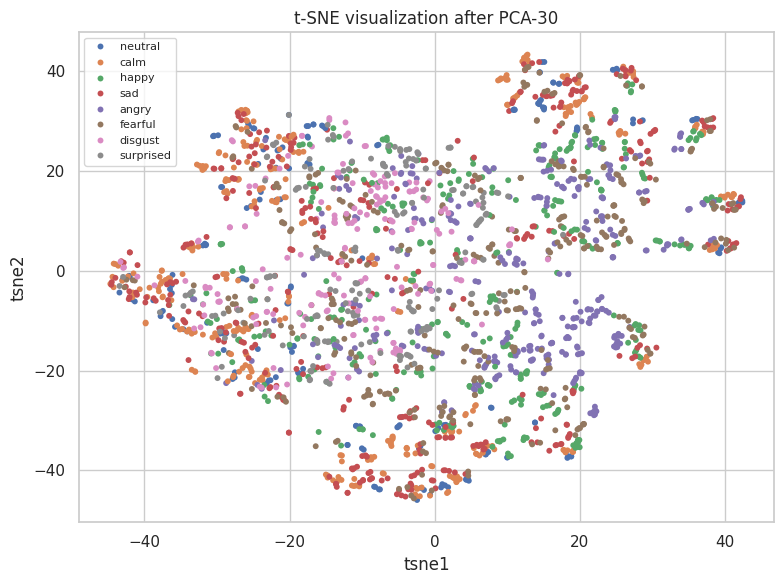

In [13]:
tsne = TSNE(
    n_components=2,
    perplexity=35,
    learning_rate="auto",
    init="pca",
    max_iter=650,
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_pca_full[:, :30])
tsne_df = pd.DataFrame({
    "tsne1": X_tsne[:, 0],
    "tsne2": X_tsne[:, 1],
    "emotion": [emotion_names[i] for i in y],
})

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="tsne1", y="tsne2", hue="emotion", s=18, linewidth=0, ax=ax)
ax.set_title("t-SNE visualization after PCA-30")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Notes for the report

- PCA is a linear compression method. It keeps directions with high variance, not necessarily directions with the most emotion information.
- PCA can make plots and distance methods cleaner, but it can also remove useful low-variance signal.
- The supervised comparison is the real test for whether PCA helps classification.
- The clustering comparison is the real test for whether PCA makes unsupervised grouping more label-aligned.
- t-SNE is useful for a slide or intuition, but I would not use it as the main evidence that a classifier is good.
- For this project, dimensionality reduction belongs in the story as analysis and optional preprocessing, not as a replacement for model validation.